### Import libraries ###

In [2]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Load Files ###

In [6]:
import pandas as pd
import os

# --- CONFIGURATION ---
DATA_FOLDER = '../Datasets'
# Generate filenames from Dataset06.csv to Dataset14.csv
FILE_NAMES = [f'Dataset{str(i).zfill(2)}.csv' for i in range(6, 15)]
all_dataframes = []

print(f"📂 Scanning folder: '{DATA_FOLDER}' for files 06 to 14...")

# 1. Loop through the specified range of files
for file_name in FILE_NAMES:
    file_path = os.path.join(DATA_FOLDER, file_name)
    
    # Check if the file exists before attempting to read
    if os.path.exists(file_path):
        try:
            # Read the CSV file
            temp_df = pd.read_csv(file_path)
            
            # Add a source column so we know which file the data came from
            temp_df['Source_File'] = file_name
            
            all_dataframes.append(temp_df)
            print(f"✅ Successfully imported: {file_name} | Rows: {len(temp_df)}")
        except Exception as e:
            print(f"❌ Error reading {file_name}: {e}")
    else:
        print(f"⚠️ Warning: {file_name} not found in {DATA_FOLDER}. Skipping.")

# 2. Combine all imported dataframes into one
if all_dataframes:
    df_raw = pd.concat(all_dataframes, ignore_index=True)
    print("\n" + "="*40)
    print("📊 COMBINED DATASET SUMMARY")
    print("="*40)
    print(f"Total rows: {df_raw.shape[0]}")
    print(f"Total columns: {df_raw.shape[1]}")
    print(f"Columns found: {list(df_raw.columns)}")
    
    # Show the first 5 rows of the merged data
    print("\n--- Raw Data Preview ---")
    display(df_raw.head())
else:
    print("❌ No data was loaded. Please check your folder path and filenames.")

# 3. Quick check for column consistency
# Most datasets should have 'Content' (or 'text') and 'Label'

📂 Scanning folder: '../Datasets' for files 06 to 14...
✅ Successfully imported: Dataset06.csv | Rows: 10000
✅ Successfully imported: Dataset07.csv | Rows: 10000
✅ Successfully imported: Dataset08.csv | Rows: 10000
✅ Successfully imported: Dataset09.csv | Rows: 10000
✅ Successfully imported: Dataset10.csv | Rows: 10000
✅ Successfully imported: Dataset11.csv | Rows: 10000
✅ Successfully imported: Dataset12.csv | Rows: 10000
✅ Successfully imported: Dataset13.csv | Rows: 1191
✅ Successfully imported: Dataset14.csv | Rows: 100

📊 COMBINED DATASET SUMMARY
Total rows: 71291
Total columns: 6
Columns found: ['url', 'type', 'Source_File', 'file_name', 'code_snippet', 'label']

--- Raw Data Preview ---


,url,type,Source_File,file_name,code_snippet,label
0,br-icloud.com.br,phishing,Dataset06.csv,NaN,NaN,NaN
1,mp3raid.com/music/krizz_kaliko.html,benign,Dataset06.csv,NaN,NaN,NaN
2,bopsecrets.org/rexroth/cr/1.htm,benign,Dataset06.csv,NaN,NaN,NaN
3,http://www.garage-pirenne.be/index.php?option=...,defacement,Dataset06.csv,NaN,NaN,NaN
4,http://adventure-nicaragua.net/index.php?optio...,defacement,Dataset06.csv,NaN,NaN,NaN


In [7]:
import pandas as pd
import os

# --- CONFIGURATION ---
MALWARE_FILE = '../Datasets/dataset_malwares.csv'
# ---------------------

print(f"🔍 Loading malware-specific data: {MALWARE_FILE}...")

if os.path.exists(MALWARE_FILE):
    try:
        # Load the malware dataset
        df_malware = pd.read_csv(MALWARE_FILE)
        
        print(f"✅ Successfully imported: {MALWARE_FILE}")
        print(f"📊 Dimensions: {df_malware.shape[0]} samples with {df_malware.shape[1]} features")
        
        # Display the first few columns to see technical features
        print("\n--- Malware Feature Preview (Technical Attributes) ---")
        # We show 'Name', 'Malware' (Label), and some PE header features
        cols_to_show = ['Name', 'Malware', 'SizeOfCode', 'ImageBase', 'SectionsLength']
        # Ensure these columns exist before displaying
        available_cols = [c for c in cols_to_show if c in df_malware.columns]
        display(df_malware[available_cols].head())
        
        # Check target distribution (0 = Benign, 1 = Malware)
        if 'Malware' in df_malware.columns:
            print("\n--- Target Distribution (Malware Column) ---")
            print(df_malware['Malware'].value_counts())
            
    except Exception as e:
        print(f"❌ Error reading {MALWARE_FILE}: {e}")
else:
    print(f"❌ File not found: {MALWARE_FILE}. Please ensure it is in the root directory.")

# SUMMARY OF DATA TYPES
print("\n" + "="*50)
print("💡 PRE-PROCESSING NOTE FOR HIEU:")
print("1. Your Spam data (06-14) uses 'Text' processing (TF-IDF).")
print("2. This Malware data uses 'Numeric' processing (PE Headers).")
print("3. For Explainable AI (SHAP), we will analyze these separately.")
print("="*50)

🔍 Loading malware-specific data: ../Datasets/dataset_malwares.csv...
✅ Successfully imported: ../Datasets/dataset_malwares.csv
📊 Dimensions: 19611 samples with 79 features

--- Malware Feature Preview (Technical Attributes) ---


,Name,Malware,SizeOfCode,ImageBase,SectionsLength
0,VirusShare_a878ba26000edaac5c98eff4432723b3,1,54784,4294967296,6
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,1,205824,4194304,5
2,VirusShare_ef84cdeba22be72a69b198213dada81a,1,24576,4194304,6
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e,1,34304,4194304,7
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb,1,8192,4194304,7



--- Target Distribution (Malware Column) ---
Malware
1    14599
0     5012
Name: count, dtype: int64

💡 PRE-PROCESSING NOTE FOR HIEU:
1. Your Spam data (06-14) uses 'Text' processing (TF-IDF).
2. This Malware data uses 'Numeric' processing (PE Headers).
3. For Explainable AI (SHAP), we will analyze these separately.


### EDA ###

C:\Users\DELL\AppData\Local\Temp\ipykernel_10600\2293822597.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, y=target_col, order=order, palette='viridis')


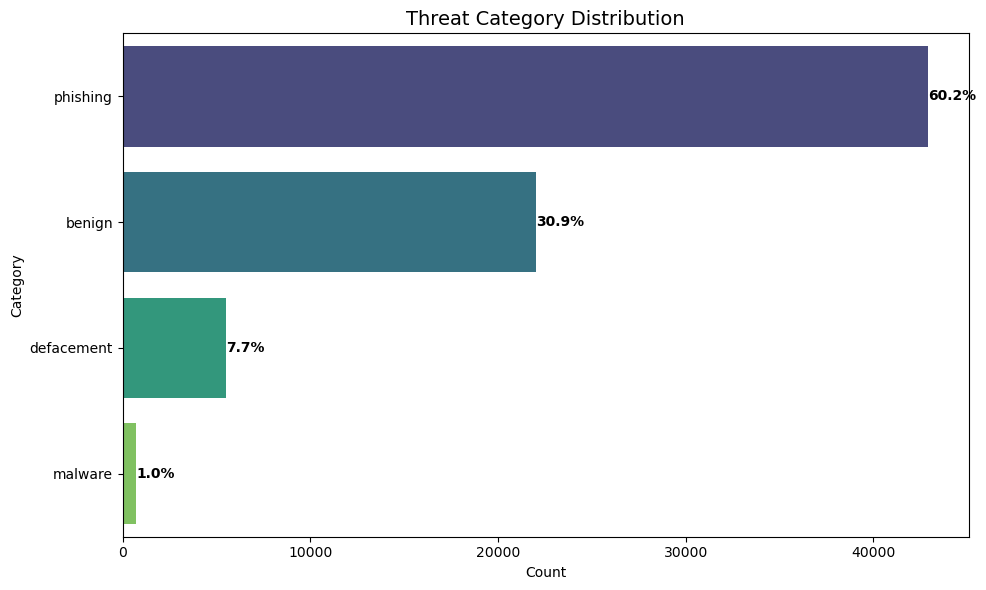

✅ Saved: ../Figures/01_class_distribution.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure Figures folder exists
FIGURES_DIR = '../Figures'
if not os.path.exists(FIGURES_DIR):
    os.makedirs(FIGURES_DIR)

# Identify target column
target_col = 'type' if 'type' in df_raw.columns else 'label'

plt.figure(figsize=(10, 6))
order = df_raw[target_col].value_counts().index
sns.countplot(data=df_raw, y=target_col, order=order, palette='viridis')

# Add percentage labels
total = len(df_raw)
for i, v in enumerate(df_raw[target_col].value_counts()):
    plt.text(v + 3, i, f'{100*v/total:.1f}%', va='center', fontweight='bold')

plt.title('Threat Category Distribution', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Category')

# Save the plot
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_class_distribution.png'), dpi=300)
plt.show()

print(f"✅ Saved: {FIGURES_DIR}/01_class_distribution.png")

C:\Users\DELL\AppData\Local\Temp\ipykernel_10600\2877046668.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='Payload_Length', y=target_col, palette='magma')


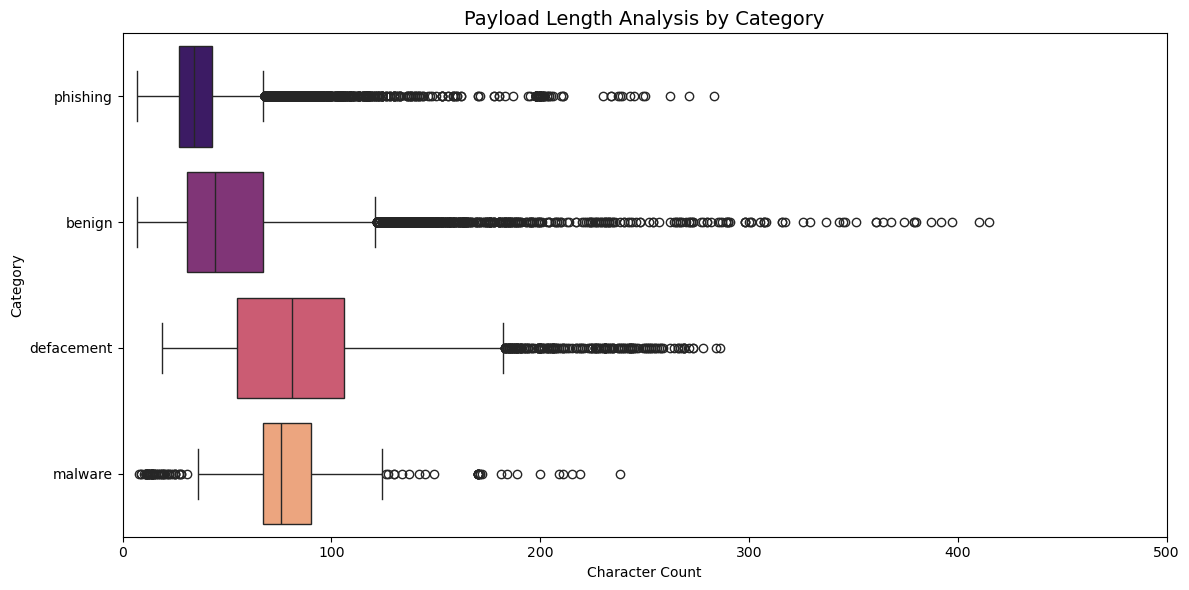

✅ Saved: ../Figures/02_payload_length_boxplot.png


In [10]:
# Feature column identification
feature_col = 'url' if 'url' in df_raw.columns else 'code_snippet'
df_raw['Payload_Length'] = df_raw[feature_col].astype(str).apply(len)

plt.figure(figsize=(12, 6))
# Using boxplot to see medians and outliers
sns.boxplot(data=df_raw, x='Payload_Length', y=target_col, palette='magma')

plt.title('Payload Length Analysis by Category', fontsize=14)
plt.xlabel('Character Count')
plt.ylabel('Category')
plt.xlim(0, 500)  # Adjust limit based on your data spread

# Save the plot
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_payload_length_boxplot.png'), dpi=300)
plt.show()

print(f"✅ Saved: {FIGURES_DIR}/02_payload_length_boxplot.png")

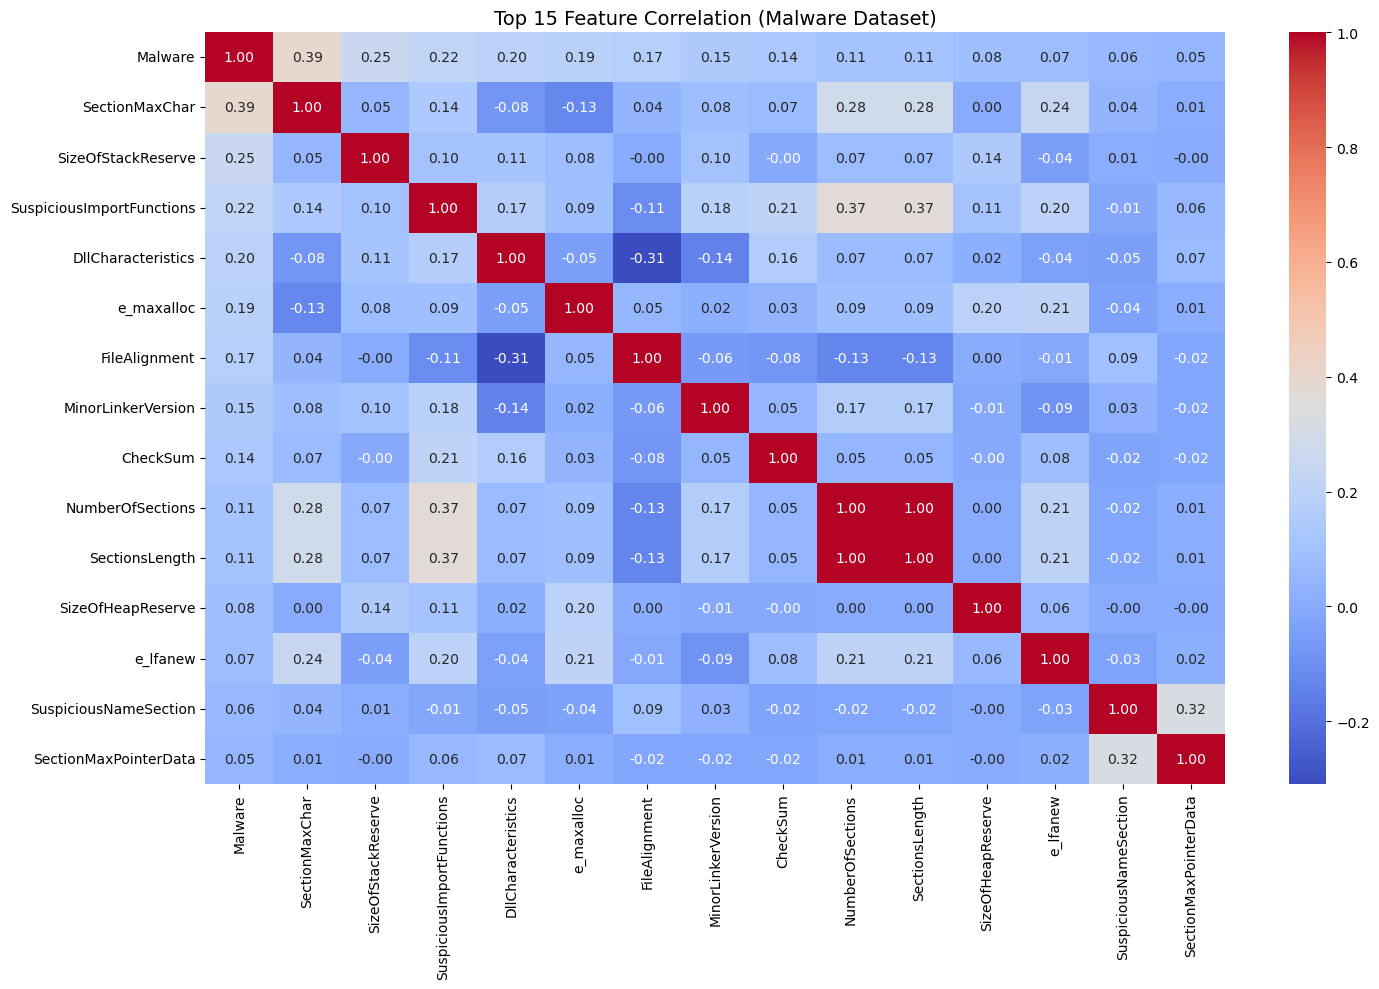

✅ Saved: ../Figures/03_malware_correlation_heatmap.png


In [11]:
if 'df_malware' in locals():
    plt.figure(figsize=(15, 10))
    
    # Select top 15 features most correlated with 'Malware' label
    # to avoid a crowded heatmap
    numeric_df = df_malware.select_dtypes(include=['number'])
    corr_matrix = numeric_df.corr()
    
    # Get top 15 features correlated with 'Malware' target
    top_features = corr_matrix['Malware'].sort_values(ascending=False).head(15).index
    
    sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    
    plt.title('Top 15 Feature Correlation (Malware Dataset)', fontsize=14)
    
    # Save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '03_malware_correlation_heatmap.png'), dpi=300)
    plt.show()
    
    print(f"✅ Saved: {FIGURES_DIR}/03_malware_correlation_heatmap.png")
else:
    print("⚠️ df_malware not found. Please run the malware dataset import cell first.")

C:\Users\DELL\AppData\Local\Temp\ipykernel_10600\2180915181.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_malware, x='Malware', palette='Set1')


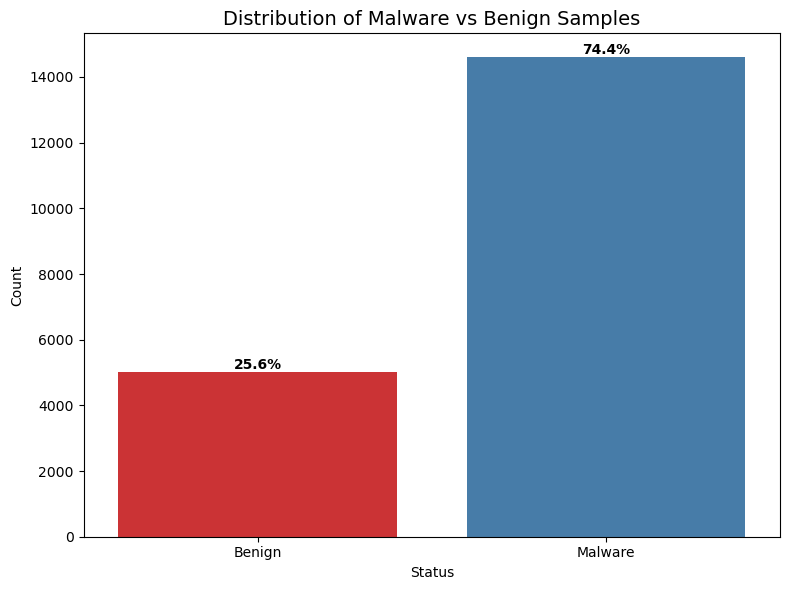

✅ Saved: ../Figures/04_malware_target_distribution.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure Figures folder exists
FIGURES_DIR = '../Figures'

# 1. Target distribution
plt.figure(figsize=(8, 6))
# 'Malware' column: 1 = Malicious, 0 = Benign
sns.countplot(data=df_malware, x='Malware', palette='Set1')

plt.xticks([0, 1], ['Benign', 'Malware'])
plt.title('Distribution of Malware vs Benign Samples', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Count')

# Add percentage labels
total_m = len(df_malware)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total_m:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height() + 100), 
                       ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_malware_target_distribution.png'), dpi=300)
plt.show()

print(f"✅ Saved: {FIGURES_DIR}/04_malware_target_distribution.png")

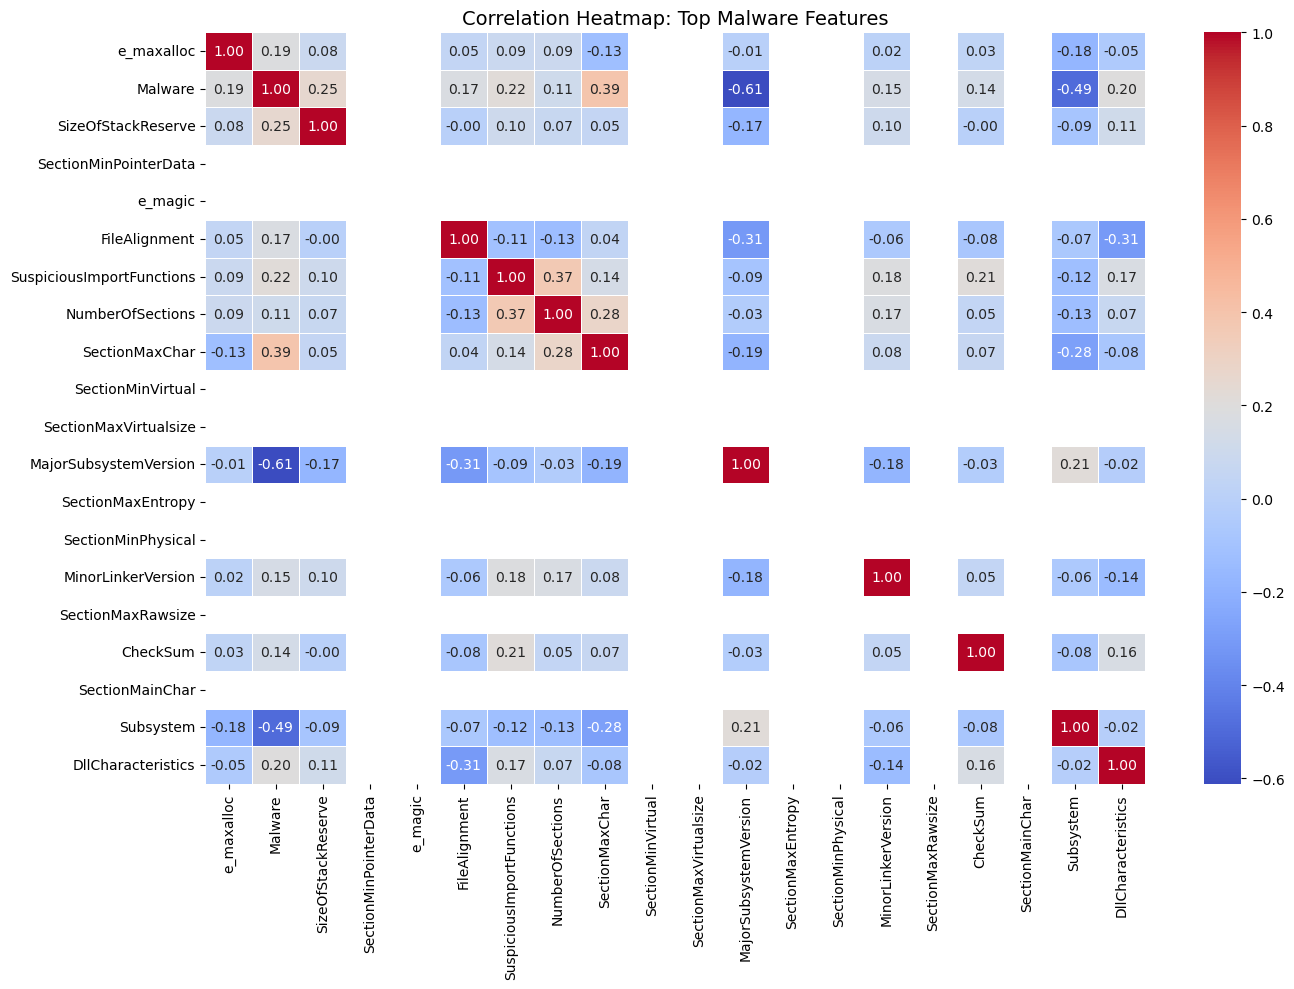

✅ Saved: ../Figures/05_malware_feature_correlation.png


In [13]:
# 2. Correlation Analysis
plt.figure(figsize=(14, 10))

# Select numeric columns and calculate correlation
numeric_cols = df_malware.select_dtypes(include=['number'])
corr = numeric_cols.corr()

# Get the top 20 features most correlated with 'Malware'
top_corr_features = corr['Malware'].sort_values(ascending=False).head(10).index.tolist()
top_corr_features += corr['Malware'].sort_values(ascending=False).tail(10).index.tolist()
top_corr_features = list(set(top_corr_features)) # Remove duplicates

sns.heatmap(df_malware[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Top Malware Features', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_malware_feature_correlation.png'), dpi=300)
plt.show()

print(f"✅ Saved: {FIGURES_DIR}/05_malware_feature_correlation.png")

C:\Users\DELL\AppData\Local\Temp\ipykernel_10600\314386264.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_malware, x='SectionMaxEntropy', hue='Malware', fill=True, ax=axes[0], palette='Set2')
C:\Users\DELL\AppData\Local\Temp\ipykernel_10600\314386264.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_malware, x='Malware', y='SizeOfCode', ax=axes[1], palette='Set1')
C:\Users\DELL\AppData\Local\Temp\ipykernel_10600\314386264.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Benign', 'Malware'])


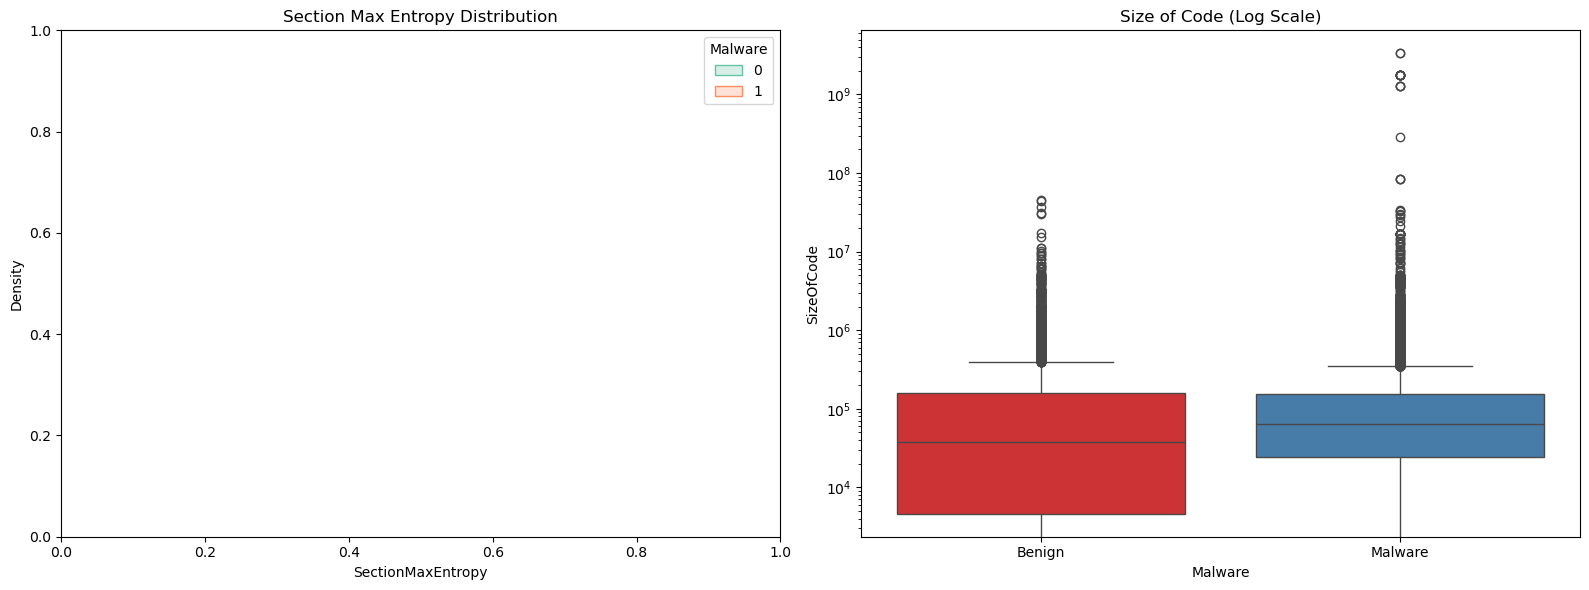

✅ Saved: ../Figures/06_malware_technical_features.png


In [14]:
# 3. Technical Feature Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Section Max Entropy (Higher entropy often means packed/encrypted malware)
sns.kdeplot(data=df_malware, x='SectionMaxEntropy', hue='Malware', fill=True, ax=axes[0], palette='Set2')
axes[0].set_title('Section Max Entropy Distribution')

# Subplot 2: Size of Code
sns.boxplot(data=df_malware, x='Malware', y='SizeOfCode', ax=axes[1], palette='Set1')
axes[1].set_yscale('log') # Log scale because sizes vary drastically
axes[1].set_title('Size of Code (Log Scale)')
axes[1].set_xticklabels(['Benign', 'Malware'])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_malware_technical_features.png'), dpi=300)
plt.show()

print(f"✅ Saved: {FIGURES_DIR}/06_malware_technical_features.png")

### Clean data ###

In [16]:
import pandas as pd

def multi_class_cleaning(df):
    clean_df = df.copy()
    
    # 1. Standardize Features (Merge url and code_snippet)
    if 'url' in clean_df.columns and 'code_snippet' in clean_df.columns:
        clean_df['payload'] = clean_df['url'].fillna(clean_df['code_snippet'])
    elif 'url' in clean_df.columns:
        clean_df['payload'] = clean_df['url']
    elif 'code_snippet' in clean_df.columns:
        clean_df['payload'] = clean_df['code_snippet']
    
    # 2. Standardize Labels
    if 'type' in clean_df.columns and 'label' in clean_df.columns:
        clean_df['raw_label'] = clean_df['type'].fillna(clean_df['label'])
    elif 'type' in clean_df.columns:
        clean_df['raw_label'] = clean_df['type']
    elif 'label' in clean_df.columns:
        clean_df['raw_label'] = clean_df['label']

    clean_df['raw_label'] = clean_df['raw_label'].astype(str).str.lower().str.strip()
    clean_df['payload'] = clean_df['payload'].astype(str).str.strip()

    # 3. Multi-class Mapping (Unique ID for each)
    # 0: Benign, 1: Malware, 2: Phishing, 3: Defacement
    multi_mapping = {
        'benign': 0,
        'malware': 1,
        'phishing': 2,
        'defacement': 3
    }
    clean_df['label_num'] = clean_df['raw_label'].map(multi_mapping)

    # 4. Final Cleanup
    clean_df = clean_df.dropna(subset=['label_num', 'payload'])
    clean_df = clean_df.drop_duplicates(subset=['payload'])

    return clean_df[['payload', 'raw_label', 'label_num']]

# Execute
df_security_cleaned = multi_class_cleaning(df_raw)

print("--- MULTI-CLASS CLEANING SUMMARY ---")
print(f"Total Unique Samples: {len(df_security_cleaned)}")
print("\n--- CLASS ID ASSIGNMENT ---")
print("0: Benign")
print("1: Malware")
print("2: Phishing")
print("3: Defacement")

print("\n--- SAMPLES PER CLASS ---")
print(df_security_cleaned['label_num'].value_counts().sort_index())

# Display sample of each to confirm the 0, 1, 2, 3 logic
display(df_security_cleaned.drop_duplicates(subset=['label_num']).sort_values('label_num'))

--- MULTI-CLASS CLEANING SUMMARY ---
Total Unique Samples: 71000

--- CLASS ID ASSIGNMENT ---
0: Benign
1: Malware
2: Phishing
3: Defacement

--- SAMPLES PER CLASS ---
label_num
0    22007
1      541
2    42930
3     5522
Name: count, dtype: int64


,payload,raw_label,label_num
1,mp3raid.com/music/krizz_kaliko.html,benign,0
38,http://www.824555.com/app/member/SportOption.p...,malware,1
0,br-icloud.com.br,phishing,2
3,http://www.garage-pirenne.be/index.php?option=...,defacement,3


In [17]:
import pandas as pd
import os

# --- CONFIGURATION ---
DATA_FOLDER = '../Datasets'
OUTPUT_FOLDER = '../Processed'
# Class ID mapping: 0: Benign, 1: Malware, 2: Phishing, 3: Defacement
MULTI_MAPPING = {
    'benign': 0,
    'malware': 1,
    'phishing': 2,
    'defacement': 3
}

# Ensure output directory exists
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"📁 Created folder: {OUTPUT_FOLDER}")

print("🚀 Starting separate cleaning and export...")

# Loop through each file from 06 to 14
for i in range(6, 15):
    original_filename = f'Dataset{str(i).zfill(2)}.csv'
    clean_filename = f'MalwareCleaned{str(i).zfill(2)}.csv'
    
    file_path = os.path.join(DATA_FOLDER, original_filename)
    export_path = os.path.join(OUTPUT_FOLDER, clean_filename)
    
    if os.path.exists(file_path):
        try:
            # 1. Read file
            df = pd.read_csv(file_path)
            
            # 2. Standardize Features (Detect url or code_snippet)
            if 'url' in df.columns:
                df['payload'] = df['url']
            elif 'code_snippet' in df.columns:
                df['payload'] = df['code_snippet']
            else:
                print(f"⚠️ Skipping {original_filename}: No valid feature column found.")
                continue
                
            # 3. Standardize Labels (Detect type or label)
            label_col = 'type' if 'type' in df.columns else ('label' if 'label' in df.columns else None)
            if label_col:
                # Convert to lowercase and strip spaces
                df['raw_label'] = df[label_col].astype(str).str.lower().str.strip()
                # Map to 0, 1, 2, 3
                df['label_num'] = df['raw_label'].map(MULTI_MAPPING)
            else:
                print(f"⚠️ Skipping {original_filename}: No valid label column found.")
                continue
            
            # 4. Final Cleanup for this specific file
            df_cleaned = df.dropna(subset=['payload', 'label_num'])
            df_cleaned = df_cleaned.drop_duplicates(subset=['payload'])
            
            # Keep only important columns
            df_final = df_cleaned[['payload', 'raw_label', 'label_num']]
            
            # 5. Export
            df_final.to_csv(export_path, index=False)
            print(f"✅ Exported: {clean_filename} | Rows: {len(df_final)}")
            
        except Exception as e:
            print(f"❌ Error processing {original_filename}: {e}")
    else:
        print(f"⚠️ File not found: {original_filename}")

print("\n" + "="*40)
print(f"✨ All files are cleaned and stored in '{OUTPUT_FOLDER}'")
print("="*40)

🚀 Starting separate cleaning and export...
✅ Exported: MalwareCleaned06.csv | Rows: 9963
✅ Exported: MalwareCleaned07.csv | Rows: 9970
✅ Exported: MalwareCleaned08.csv | Rows: 9964
✅ Exported: MalwareCleaned09.csv | Rows: 10000
✅ Exported: MalwareCleaned10.csv | Rows: 10000
✅ Exported: MalwareCleaned11.csv | Rows: 10000
✅ Exported: MalwareCleaned12.csv | Rows: 10000
✅ Exported: MalwareCleaned13.csv | Rows: 1191
✅ Exported: MalwareCleaned14.csv | Rows: 14

✨ All files are cleaned and stored in '../Processed'


In [18]:
import pandas as pd
import os

# --- CONFIGURATION ---
INPUT_FILE = '../Datasets/dataset_malwares.csv'
OUTPUT_FOLDER = '../Processed'
OUTPUT_FILE = 'MalwareCleaned15.csv'
EXPORT_PATH = os.path.join(OUTPUT_FOLDER, OUTPUT_FILE)

# 1. Check if df_malware exists, if not, load it
if 'df_malware' not in locals():
    if os.path.exists(INPUT_FILE):
        df_malware = pd.read_csv(INPUT_FILE)
    else:
        print(f"❌ Cannot find {INPUT_FILE}")

def clean_numeric_malware(df):
    clean_df = df.copy()
    
    # 2. Handle missing values for numeric columns (fill with 0 or median)
    numeric_cols = clean_df.select_dtypes(include=['number']).columns
    clean_df[numeric_cols] = clean_df[numeric_cols].fillna(0)
    
    # 3. Standardize the target column
    # In this dataset, 'Malware' is already 0 and 1. 
    # We rename it to 'label_num' to match our other datasets
    clean_df['label_num'] = clean_df['Malware']
    
    # 4. Remove non-numeric identifier columns that aren't useful for training
    # But we keep 'Name' if we need it for XAI reference later
    cols_to_keep = ['Name', 'label_num'] + [c for c in numeric_cols if c != 'Malware']
    
    return clean_df[cols_to_keep]

# Execute cleaning
if 'df_malware' in locals():
    df_malware_cleaned = clean_numeric_malware(df_malware)
    print("✅ Numeric cleaning complete.")
    print(f"📊 Features remaining: {df_malware_cleaned.shape[1]}")

✅ Numeric cleaning complete.
📊 Features remaining: 79


In [19]:
# 5. Export to Processed folder
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

try:
    df_malware_cleaned.to_csv(EXPORT_PATH, index=False)
    
    print("="*40)
    print(f"✨ EXPORT SUCCESSFUL: {OUTPUT_FILE}")
    print(f"📍 Location: {EXPORT_PATH}")
    print(f"🔢 Target Distribution (0: Benign, 1: Malware):")
    print(df_malware_cleaned['label_num'].value_counts())
    print("="*40)
    
    # Preview to make sure it's clean
    display(df_malware_cleaned.head(3))
except Exception as e:
    print(f"❌ Error during export: {e}")

✨ EXPORT SUCCESSFUL: MalwareCleaned15.csv
📍 Location: ../Processed\MalwareCleaned15.csv
🔢 Target Distribution (0: Benign, 1: Malware):
label_num
1    14599
0     5012
Name: count, dtype: int64


,Name,label_num,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
0,VirusShare_a878ba26000edaac5c98eff4432723b3,1,23117,144,3,0,4,0,65535,0,...,3758096608,0,7,152,0,0,54440,77824,73728,0
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,1,23117,144,3,0,4,0,65535,0,...,3791650880,0,16,311,0,0,262276,294912,0,346112
2,VirusShare_ef84cdeba22be72a69b198213dada81a,1,23117,144,3,0,4,0,65535,0,...,3221225536,0,6,176,0,0,36864,40960,0,0


### Training ###

In [72]:
import re

# 1. Trích xuất đặc trưng từ MalSigs.txt
with open('../Datasets/MalSigs.txt', 'r', encoding='utf-8') as f:
    sigs_raw = [line.strip().lower() for line in f if line.strip() and not line.startswith('#')]

voc_sigs = set()
for item in sigs_raw:
    # Tách nhỏ các cụm từ thành từ đơn (tokenization)
    words = re.findall(r'\w+', item)
    voc_sigs.update(words)

voc_sigs_final = list(voc_sigs)
print(f"✅ Đã chuẩn bị xong {len(voc_sigs_final)} từ khóa từ MalSigs.txt")

✅ Đã chuẩn bị xong 98 từ khóa từ MalSigs.txt


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Khởi tạo Vectorizer Hybrid
# ngram_range=(1, 3) giúp bắt được các cụm lệnh dài cực nhạy
vectorizer = TfidfVectorizer(
    max_features=20000, 
    ngram_range=(1, 3), 
    stop_words='english'
)

# 2. Biến đổi dữ liệu (df_train_final là dữ liệu gộp 06-15 ông đã làm ở trên)
X = vectorizer.fit_transform(df_train_final['payload'].astype(str))
y = df_train_final['label_num'].astype(int)

# 3. Split 20% ra để test nội bộ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Đã chuẩn bị xong ma trận dữ liệu:")
print(f"--- Tập Train: {X_train.shape[0]} mẫu")
print(f"--- Tập Test: {X_test.shape[0]} mẫu")

✅ Đã chuẩn bị xong ma trận dữ liệu:
--- Tập Train: 72570 mẫu
--- Tập Test: 18143 mẫu


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Khởi tạo Model (dùng n_jobs=-1 để chạy đa nhân cho nhanh)
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# 2. Huấn luyện
print("⏳ Đang huấn luyện Model... Cà phê tí nhé ông!")
model.fit(X_train, y_train)

# 3. Dự đoán và chấm điểm trên tập 20%
y_pred = model.predict(X_test)
print(f"⭐ ĐỘ CHÍNH XÁC (ACCURACY): {accuracy_score(y_test, y_pred):.2%}")
print("\n📊 BÁO CÁO CHI TIẾT:")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Malware', 'Phishing', 'Defacement']))

⏳ Đang huấn luyện Model... Cà phê tí nhé ông!
⭐ ĐỘ CHÍNH XÁC (ACCURACY): 93.66%

📊 BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

        Safe       0.88      0.92      0.90      5404
     Malware       0.95      0.97      0.96      3048
    Phishing       0.96      0.93      0.95      8586
  Defacement       0.97      0.99      0.98      1105

    accuracy                           0.94     18143
   macro avg       0.94      0.95      0.95     18143
weighted avg       0.94      0.94      0.94     18143



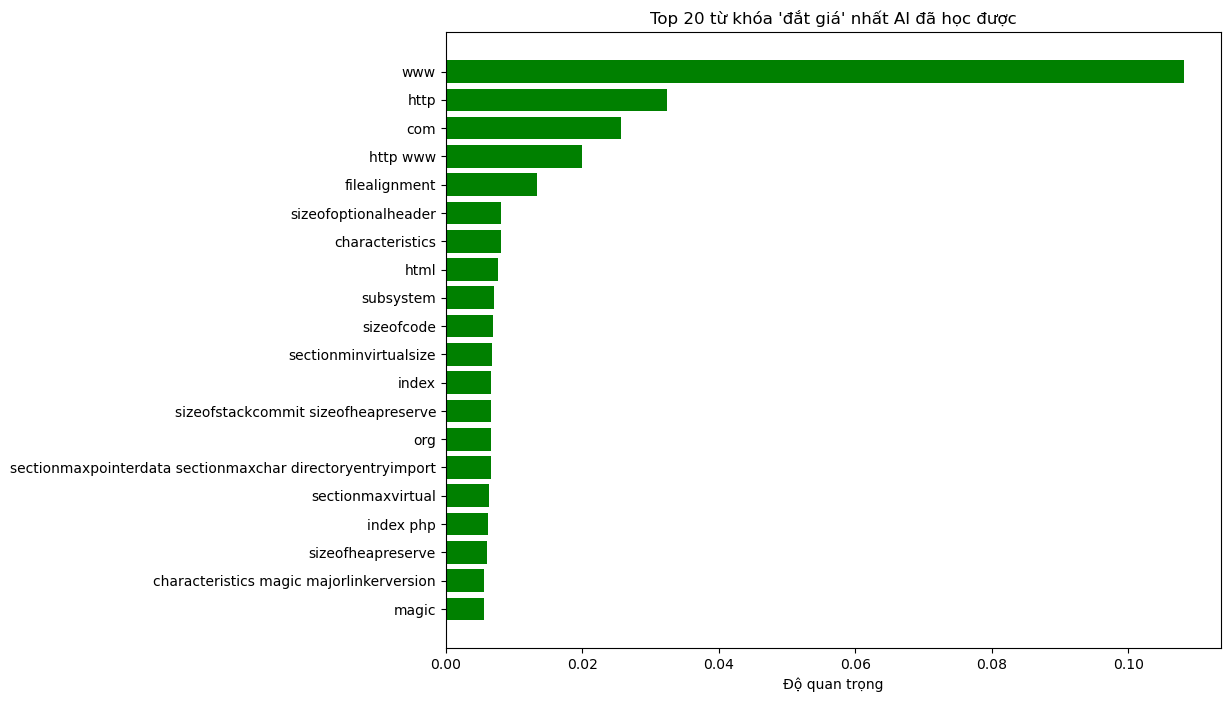

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Lấy top 20 đặc trưng quan trọng nhất
importances = model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.title("Top 20 từ khóa 'đắt giá' nhất AI đã học được")
plt.barh(range(len(indices)), importances[indices], color='green', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Độ quan trọng')
plt.show()

In [76]:
# Chạy cell này để test trên file Test08.csv
import os

test_path = '../TestData/Test08.csv'
if os.path.exists(test_path):
    df_final_test = pd.read_csv(test_path)
    # Chuẩn hóa payload
    df_final_test['payload'] = df_final_test['File_Content'].astype(str)
    
    # Dùng vectorizer hybrid để biến đổi
    X_final_test = vectorizer.transform(df_final_test['payload'])
    
    # Dự đoán
    y_final_pred = model.predict(X_final_test)
    
    # Đánh giá
    print("🚀 KẾT QUẢ KIỂM THỬ CUỐI CÙNG TRÊN TEST08:")
    print(classification_report(df_final_test['Label'].astype(int), y_final_pred))
else:
    print("Không tìm thấy file Test08 để kiểm thử!")

🚀 KẾT QUẢ KIỂM THỬ CUỐI CÙNG TRÊN TEST08:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         4
           2       0.25      1.00      0.40         2
           3       0.00      0.00      0.00         1

    accuracy                           0.22         9
   macro avg       0.06      0.25      0.10         9
weighted avg       0.06      0.22      0.09         9



c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [80]:
import joblib
import os

# 1. Tạo folder Model nếu chưa tồn tại
model_folder = '../Models/'
if not os.path.exists(model_folder):
    os.makedirs(model_folder)
    print(f"📁 Đã tạo thư mục mới: {model_folder}")

# 2. Định nghĩa đường dẫn lưu file
model_path = os.path.join(model_folder, 'malware_detector_model.pkl')
vectorizer_path = os.path.join(model_folder, 'malware_vectorizer.pkl')

try:
    # 3. Tiến hành lưu
    joblib.dump(model, model_path)
    joblib.dump(vectorizer, vectorizer_path)
    
    print("="*40)
    print("✨ EXPORT MODEL THÀNH CÔNG!")
    print(f"📍 Model: {model_path}")
    print(f"📍 Vectorizer: {vectorizer_path}")
    print("="*40)
    print("💡 Lưu ý: Khi sử dụng ở file khác, ông phải load cả 2 file này lên cùng lúc nhé.")
    
except Exception as e:
    print(f"❌ Có lỗi khi lưu Model: {e}")

✨ EXPORT MODEL THÀNH CÔNG!
📍 Model: ../Models/malware_detector_model.pkl
📍 Vectorizer: ../Models/malware_vectorizer.pkl
💡 Lưu ý: Khi sử dụng ở file khác, ông phải load cả 2 file này lên cùng lúc nhé.
